In [19]:
import sys
import os
import numpy as np
sys.path.append(os.path.abspath(".."))

from src.evaluation_utils import (
    safety_mae,
    risk_loss,
    count_dangerous_overestimates,
    avg_overestimate_magnitude,
    catastrophic_risk_index
)

In [1]:
import pickle

with open("../data/processed/predictions.pkl", "rb") as f:
    preds = pickle.load(f)

y_val = preds["y_val"]
y_preds_lr = preds["Linear Regression"]
y_preds_dr = preds["Decision Tree"]
y_preds_fr = preds["Random Forest"]
y_preds_gbr = preds["Gradient Boosting"]


In [2]:

residuals = {
    "Linear Regression": y_val - y_preds_lr,
    "Decision Tree": y_val - y_preds_dr,
    "Random Forest": y_val - y_preds_fr,
    "Gradient Boosting": y_val - y_preds_gbr
}
residuals



{'Linear Regression': 0         9.634318
 1        12.918703
 2         5.471656
 3        -6.502409
 4        13.469984
            ...    
 18510   -19.981249
 18511    -9.872025
 18512    -3.080375
 18513     0.150317
 18514    -0.156036
 Name: RUL, Length: 4070, dtype: float64,
 'Decision Tree': 0        17.955945
 1        17.955945
 2        10.230252
 3         4.585261
 4        10.230252
            ...    
 18510    -4.256944
 18511    -5.256944
 18512    -6.256944
 18513    -3.191882
 18514    -4.191882
 Name: RUL, Length: 4070, dtype: float64,
 'Random Forest': 0        12.18
 1        12.21
 2         3.93
 3         8.80
 4         7.12
          ...  
 18510    -6.33
 18511    -1.74
 18512    -2.04
 18513    -0.58
 18514    -1.83
 Name: RUL, Length: 4070, dtype: float64,
 'Gradient Boosting': 0        8.825888
 1        9.041256
 2        6.830296
 3        5.523788
 4        9.417865
            ...   
 18510   -6.424216
 18511   -2.375262
 18512   -2.935068
 18513   -0

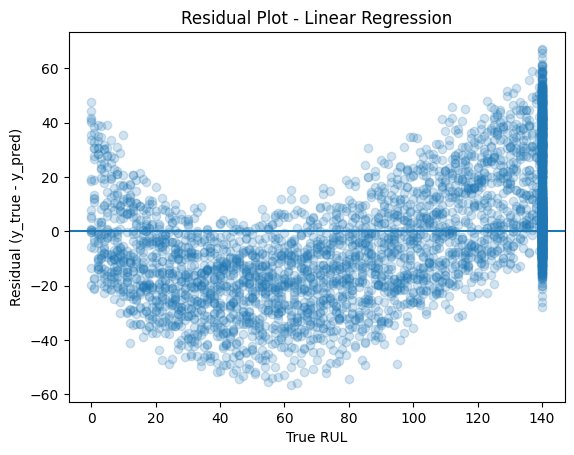

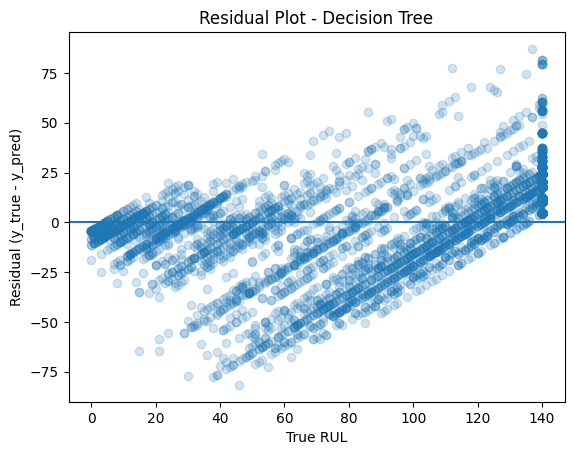

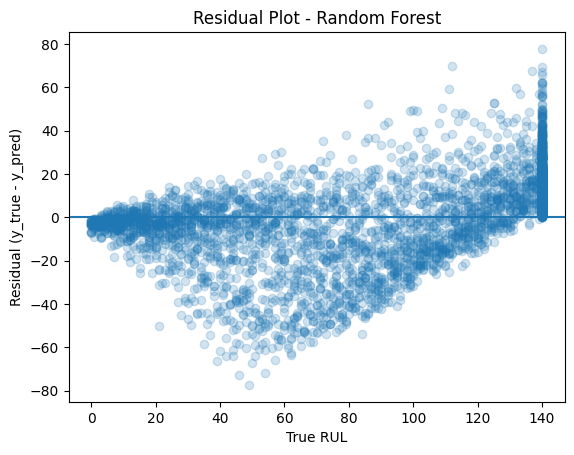

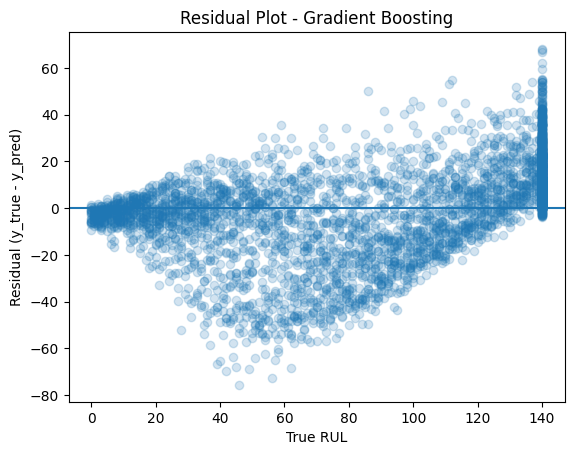

In [3]:
import matplotlib.pyplot as plt

for model_name, res in residuals.items():
    plt.figure()
    plt.scatter(y_val, res, alpha=0.2)
    plt.axhline(0)   # perfect prediction line
    plt.xlabel("True RUL")
    plt.ylabel("Residual (y_true - y_pred)")
    plt.title(f"Residual Plot - {model_name}")
    plt.show()


In [4]:
import pandas as pd

df_res = pd.DataFrame({
    "y_val": y_val,
    "residual_lr": y_val - y_preds_lr
})

df_res["rul_bin"] = pd.cut(df_res["y_val"], bins=10)

df_res.groupby("rul_bin")["residual_lr"].mean()


C:\Users\Hp\AppData\Local\Temp\ipykernel_16076\3421793186.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_res.groupby("rul_bin")["residual_lr"].mean()


rul_bin
(-0.14, 14.0]      0.355150
(14.0, 28.0]     -14.915600
(28.0, 42.0]     -21.211237
(42.0, 56.0]     -22.449298
(56.0, 70.0]     -20.124427
(70.0, 84.0]     -15.801881
(84.0, 98.0]      -8.199643
(98.0, 112.0]      0.364765
(112.0, 126.0]    10.031123
(126.0, 140.0]    16.710234
Name: residual_lr, dtype: float64

In [7]:
models = {
    "Linear Regression": y_preds_lr,
    "Decision Tree": y_preds_dr,
    "Random Forest": y_preds_fr,
    "Gradient Boosting": y_preds_gbr
}


In [8]:
safety_results = []

for model_name, y_pred in models.items():
    score = safety_mae(y_val, y_pred)
    safety_results.append([model_name, score])

df_safety = pd.DataFrame(
    safety_results,
    columns=["Model", "Safety-MAE"]
).sort_values("Safety-MAE")

df_safety


,Model,Safety-MAE
3,Gradient Boosting,22.608727
2,Random Forest,22.708700
1,Decision Tree,26.254659
0,Linear Regression,28.258486


In [9]:
lambda_values = [1, 2, 3, 5]
gamma_values = [0.01, 0.05, 0.1]

for lambda_ in lambda_values:
    for gamma in gamma_values:
        print(f"\nLambda = {lambda_}, Gamma = {gamma}")
        print("-" * 40)

        results = []

        for model_name, y_pred in models.items():
            loss = risk_loss(y_val, y_pred, lambda_, gamma)
            results.append((model_name, loss))

        results = sorted(results, key=lambda x: x[1])

        for model_name, loss in results:
            print(f"{model_name}: {loss:.4f}")



Lambda = 1, Gamma = 0.01
----------------------------------------
Gradient Boosting: 11.6687
Random Forest: 11.7767
Decision Tree: 13.4158
Linear Regression: 14.7860

Lambda = 1, Gamma = 0.05
----------------------------------------
Gradient Boosting: 8.3384
Random Forest: 8.4353
Decision Tree: 9.4741
Linear Regression: 10.6153

Lambda = 1, Gamma = 0.1
----------------------------------------
Gradient Boosting: 7.9044
Random Forest: 7.9807
Decision Tree: 8.9144
Linear Regression: 9.8355

Lambda = 2, Gamma = 0.01
----------------------------------------
Gradient Boosting: 15.6434
Random Forest: 15.7960
Decision Tree: 18.2502
Linear Regression: 20.1808

Lambda = 2, Gamma = 0.05
----------------------------------------
Gradient Boosting: 8.9828
Random Forest: 9.1133
Decision Tree: 10.3668
Linear Regression: 11.8394

Lambda = 2, Gamma = 0.1
----------------------------------------
Gradient Boosting: 8.1149
Random Forest: 8.2040
Decision Tree: 9.2475
Linear Regression: 10.2798

Lambda = 3,

In [10]:
thresholds = [20, 10, 5]

for threshold in thresholds:
    print(f"\nOverestimations when RUL < {threshold}")
    print("-" * 40)

    for model_name, y_pred in models.items():
        count = count_dangerous_overestimates(y_val, y_pred, threshold)
        print(f"{model_name}: {count}")



Overestimations when RUL < 20
----------------------------------------
Linear Regression: 239
Decision Tree: 302
Random Forest: 315
Gradient Boosting: 281

Overestimations when RUL < 10
----------------------------------------
Linear Regression: 101
Decision Tree: 180
Random Forest: 177
Gradient Boosting: 163

Overestimations when RUL < 5
----------------------------------------
Linear Regression: 43
Decision Tree: 100
Random Forest: 96
Gradient Boosting: 89


In [11]:
threshold = 5

print(f"\nCatastrophic Risk Index (RUL < {threshold})")
print("-" * 50)

for model_name, y_pred in models.items():
    cri = catastrophic_risk_index(y_val, y_pred, threshold)
    print(f"{model_name}: {cri:.4f}")



Catastrophic Risk Index (RUL < 5)
--------------------------------------------------
Linear Regression: 4.3192
Decision Tree: 5.8089
Random Forest: 3.2065
Gradient Boosting: 3.3757


In [12]:
def evaluate_all_models(models, y_val):
    results = []

    for name, y_pred in models.items():
        results.append([
            name,
            safety_mae(y_val, y_pred),
            catastrophic_risk_index(y_val, y_pred, threshold=5)
        ])

    return pd.DataFrame(
        results,
        columns=["Model", "Safety-MAE", "CRI@5"]
    ).sort_values("CRI@5")


In [13]:
evaluate_all_models(models, y_val)


,Model,Safety-MAE,CRI@5
2,Random Forest,22.708700,3.206500
3,Gradient Boosting,22.608727,3.375692
0,Linear Regression,28.258486,4.319209
1,Decision Tree,26.254659,5.808852


In [14]:
def residual_bias_curve(y_true, y_pred, bins=15):
    df_temp = pd.DataFrame({
        "y_true": y_true,
        "residual": y_true - y_pred
    })
    
    df_temp["rul_bin"] = pd.cut(df_temp["y_true"], bins=bins)
    
    return df_temp.groupby("rul_bin")["residual"].mean()


In [15]:
for name, y_pred in models.items():
    bias = residual_bias_curve(y_val, y_pred)
    print(f"\n{name}")
    print(bias)



Linear Regression
rul_bin
(-0.14, 9.333]         4.027044
(9.333, 18.667]       -9.013968
(18.667, 28.0]       -16.263588
(28.0, 37.333]       -20.390737
(37.333, 46.667]     -22.893946
(46.667, 56.0]       -22.168535
(56.0, 65.333]       -20.520963
(65.333, 74.667]     -18.633783
(74.667, 84.0]       -15.057561
(84.0, 93.333]        -9.549547
(93.333, 102.667]     -4.596541
(102.667, 112.0]       1.762651
(112.0, 121.333]       7.825222
(121.333, 130.667]    14.906080
(130.667, 140.0]      16.747406
Name: residual, dtype: float64

Decision Tree
rul_bin
(-0.14, 9.333]        -5.261653
(9.333, 18.667]       -4.572539
(18.667, 28.0]        -6.645184
(28.0, 37.333]        -9.056477
(37.333, 46.667]     -16.198243
(46.667, 56.0]       -19.972251
(56.0, 65.333]       -21.415240
(65.333, 74.667]     -20.555180
(74.667, 84.0]       -18.812069
(84.0, 93.333]       -13.416547
(93.333, 102.667]     -9.491703
(102.667, 112.0]      -3.398421
(112.0, 121.333]       2.347419
(121.333, 130.667]     

C:\Users\Hp\AppData\Local\Temp\ipykernel_16076\1945744066.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df_temp.groupby("rul_bin")["residual"].mean()
C:\Users\Hp\AppData\Local\Temp\ipykernel_16076\1945744066.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  return df_temp.groupby("rul_bin")["residual"].mean()
C:\Users\Hp\AppData\Local\Temp\ipykernel_16076\1945744066.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this

In [16]:
def residual_variance_curve(y_true, y_pred, bins=15):
    df_temp = pd.DataFrame({
        "y_true": y_true,
        "residual": y_true - y_pred
    })
    
    df_temp["rul_bin"] = pd.cut(df_temp["y_true"], bins=bins)
    
    return df_temp.groupby("rul_bin")["residual"].std()


In [20]:
for name, y_pred in models.items():
    corr = np.corrcoef(y_val, y_val - y_pred)[0,1]
    print(f"{name} Residual Correlation: {corr:.4f}")


Linear Regression Residual Correlation: 0.5331
Decision Tree Residual Correlation: 0.4847
Random Forest Residual Correlation: 0.4788
Gradient Boosting Residual Correlation: 0.4558


In [21]:
def overestimation_rate_curve(y_true, y_pred, bins=15):
    df_temp = pd.DataFrame({
        "y_true": y_true,
        "residual": y_true - y_pred
    })
    
    df_temp["rul_bin"] = pd.cut(df_temp["y_true"], bins=bins)
    
    return df_temp.groupby("rul_bin").apply(
        lambda x: np.mean(x["residual"] < 0)
    )
